In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:
df_transac = pd.read_csv('data/train_transaction.csv', nrows=50000)
df_id = pd.read_csv('data/train_identity.csv', nrows=50000)

print(df_id.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [95]:
print(f"Dimensions df_id : {df_id.shape}")

Dimensions df_id : (50000, 41)


In [96]:
df_combined = df_id.merge(df_transac[['TransactionID', 'isFraud']], on='TransactionID', how='left')


In [97]:
const_cols = [col for col in df_combined.columns if df_combined[col].nunique(dropna=True) <= 1]

print(f"Colonnes constantes (ou vides) : {const_cols}")

# Si la liste n'est plus vide, tu peux maintenant les supprimer proprement
if len(const_cols) > 0:
    df_combined.drop(columns=const_cols, inplace=True)
    print(f"{len(const_cols)} removed column.")
else:
    print("No one constant column found.")

Colonnes constantes (ou vides) : []
No one constant column found.


We will sort continuous data and categorical data. if the variables is an object type, it is cateogrical. However, if it is a numerical type, we can have a look on the number of unique values tu determine if it is a categorical or continuous variable.
We create two different lists to analyse them.

In [ ]:
CARDINALITY_THRESHOLD = 20

cat_cols = []
num_cols = []

for col in df_combined.columns:

    if df_combined[col].dtype == 'object':
        cat_cols.append(col)
    

    else:
        if df_combined[col].nunique() < CARDINALITY_THRESHOLD:
  
            cat_cols.append(col)
        else:

            num_cols.append(col)

In [99]:
print(df_id.nunique())

TransactionID    50000
id_01               54
id_02            44372
id_03               20
id_04               15
id_05               82
id_06               96
id_07               66
id_08               90
id_09               34
id_10               48
id_11              293
id_12                2
id_13               43
id_14               24
id_15                3
id_16                2
id_17               78
id_18               14
id_19              454
id_20              248
id_21              291
id_22               10
id_23                3
id_24                7
id_25              224
id_26               64
id_27                2
id_28                2
id_29                2
id_30               67
id_31               84
id_32                4
id_33              146
id_34                4
id_35                2
id_36                2
id_37                2
id_38                2
DeviceType           2
DeviceInfo         944
dtype: int64


In [100]:
print("number of categorical variables: ", len(cat_cols))
print("number of continuous variables: ", len(num_cols))

number of categorical variables:  19
number of continuous variables:  23


In [101]:
total_cols = len(df_id.columns)
somme_triee = len(cat_cols) + len(num_cols)

print(f"Total des colonnes dans le DataFrame : {total_cols}")
print(f"Somme des deux listes : {somme_triee}")

if total_cols == somme_triee:
    print("✅ Le tri est complet, aucune colonne n'a été oubliée.")
else:
    print("⚠️ Attention, il y a un écart ! Vérifie ton script de tri.")

Total des colonnes dans le DataFrame : 41
Somme des deux listes : 42
⚠️ Attention, il y a un écart ! Vérifie ton script de tri.


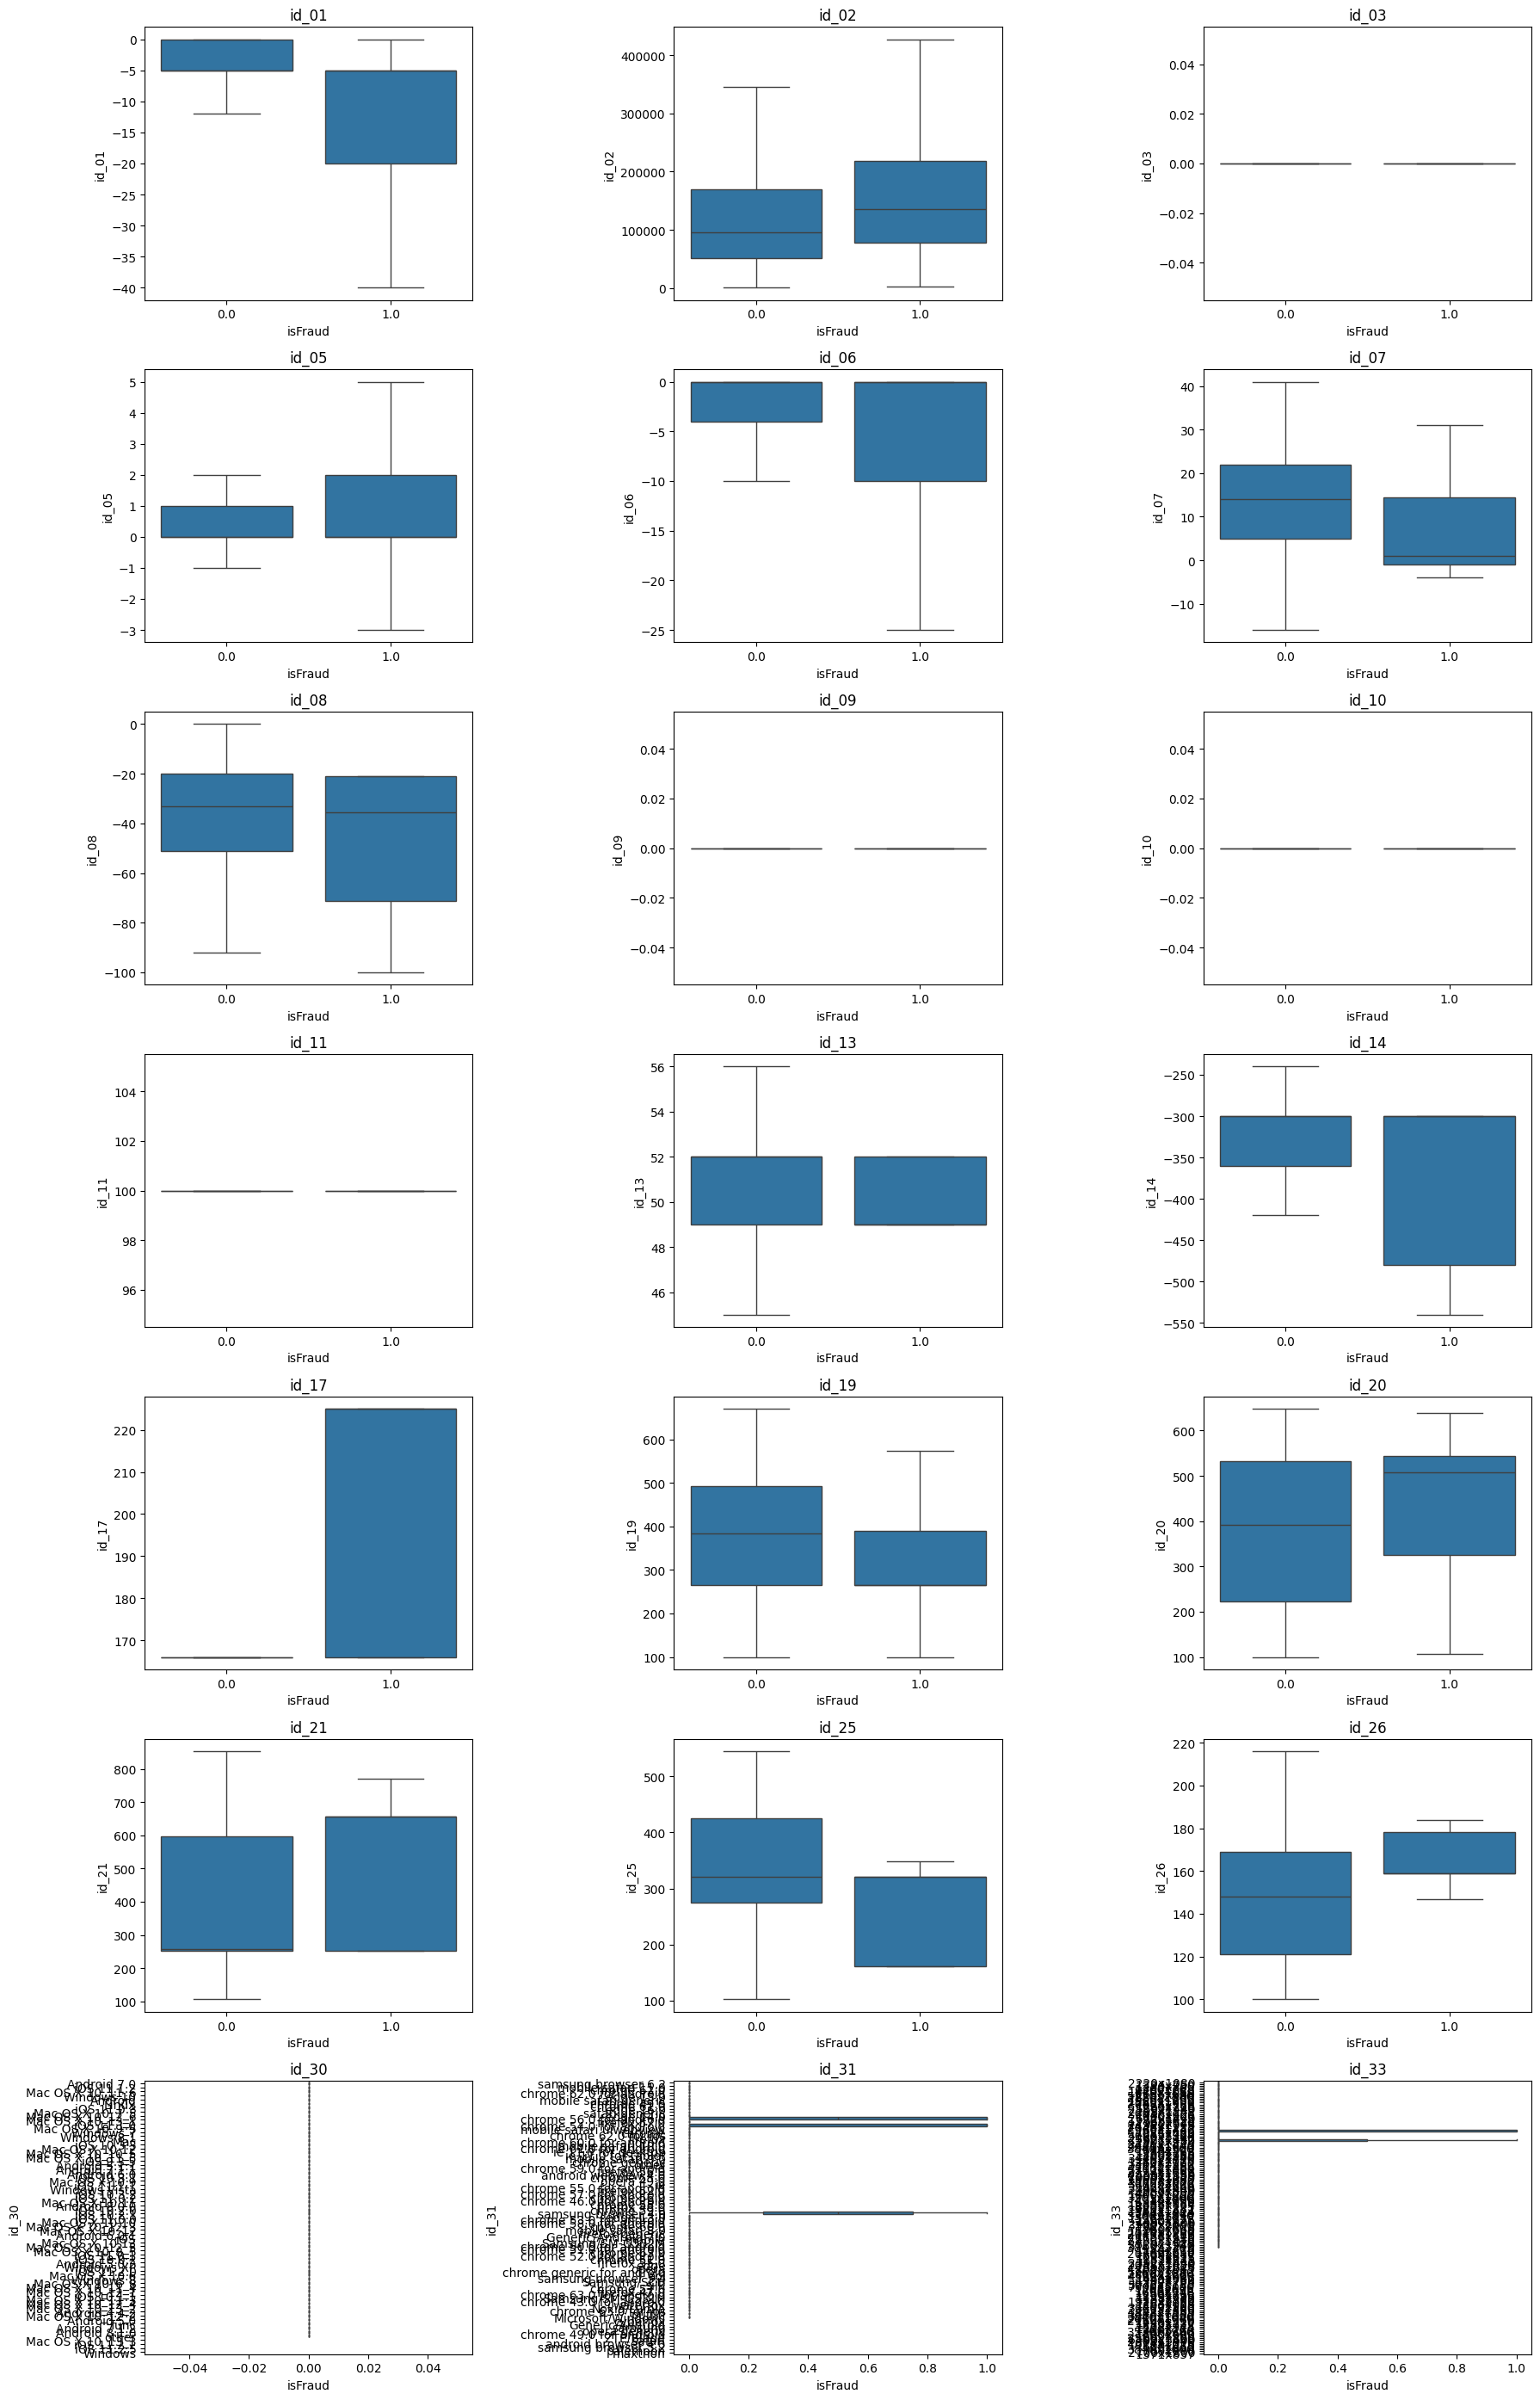

In [ ]:

id_cols = [col for col in df_combined.columns if col.startswith('id_') or col == 'isFraud']
df_id_only = df_combined[id_cols]


cat_id_cols = [col for col in id_cols if df_id_only[col].dtype == 'object' or df_id_only[col].nunique() < 20]
num_id_cols = [col for col in id_cols if col not in cat_id_cols and col != 'isFraud']


cols_to_plot = [c for c in num_id_cols if c != 'isFraud']

n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() # Pour manipuler les axes comme une liste simple

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='isFraud', y=col, data=df_id_only, ax=axes[i], showfliers=False)
    axes[i].set_title(col)

# Supprimer les axes vides si le nombre de variables n'est pas un multiple de 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

id_30, id31 and id33 are variables with a lot of categories. We will regroup some of them.

id_03, id_09, id_10 and id_11 are completely flat, we will analyse them.

First, id_33 is the resolution. The computer can understand the size if we separate this variable in three: the width, the height, and the screen pixels.

In [119]:
df_combined['id_33'] = df_combined['id_33'].fillna('0x0')

res_split = df_combined['id_33'].str.split('x', expand=True)

df_combined['screen_width'] = res_split[0].astype(int)
df_combined['screen_height'] = res_split[1].astype(int)

df_combined['screen_pixels'] = df_combined['screen_width'] * df_combined['screen_height']

df_combined.drop(columns=['id_33'], inplace=True)

In [ ]:

print(df_combined.groupby('screen_pixels')['isFraud'].mean().sort_values(ascending=False).head(10))

screen_pixels
614400     0.350000
384480     0.285714
410400     0.114286
921600     0.086957
2251125    0.080882
0          0.080376
8294400    0.076923
2742336    0.066794
1044480    0.037037
2304000    0.037037
Name: isFraud, dtype: float64


Transactions with the screen pixels 614 400 are more likely to be a fraud.

Then we will simplify id_30 and id_31 because it is categorical.



In [133]:
def simplify_os(val):
    val = str(val).lower()
    if 'android' in val: return 'Android'
    if 'ios' in val: return 'iOS'
    if 'mac' in val: return 'Mac'
    if 'windows' in val: return 'Windows'
    if 'linux' in val: return 'Linux'
    return 'Other'

def simplify_browser(val):
    val = str(val).lower()
    if 'chrome' in val: return 'Chrome'
    if 'firefox' in val: return 'Firefox'
    if 'safari' in val: return 'Safari'
    if 'edge' in val: return 'Edge'
    if 'samsung' in val: return 'Samsung'
    return 'Other'


df_combined['os_family'] = df_combined['id_30'].apply(simplify_os)
df_combined['browser_family'] = df_combined['id_31'].apply(simplify_browser)

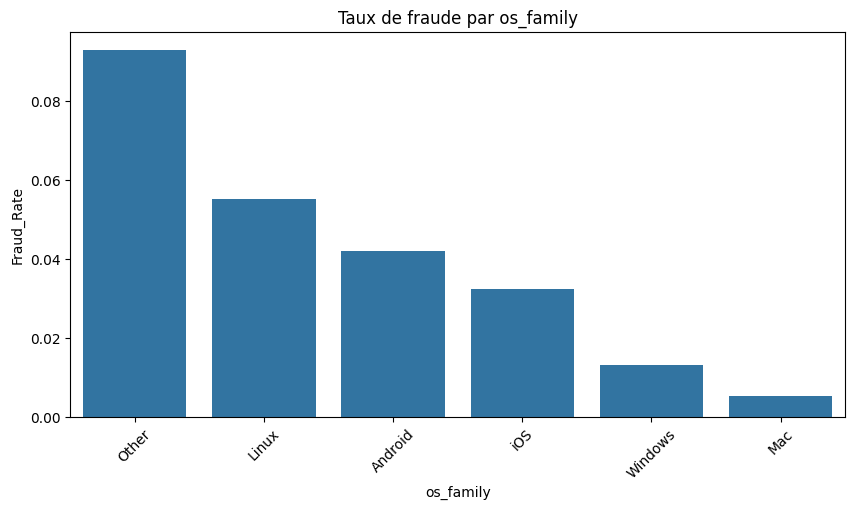

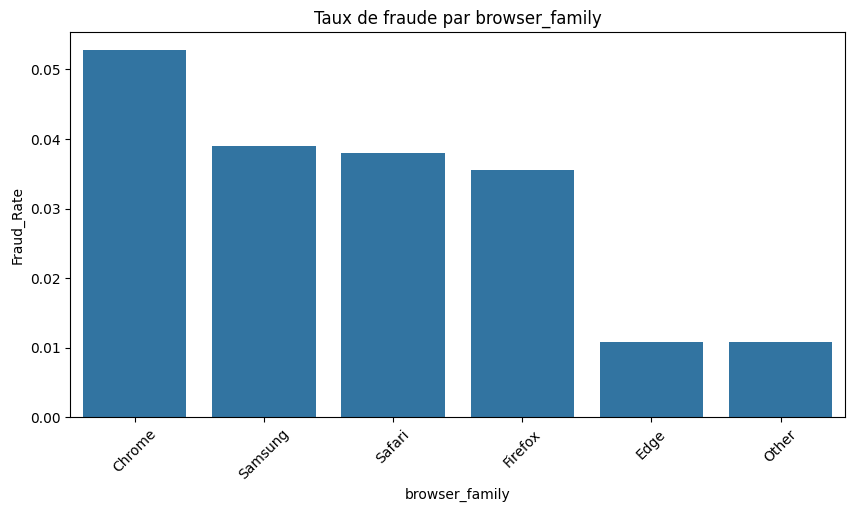

In [136]:
for col in ['os_family', 'browser_family']:

    data_plot = df_combined.groupby(col, observed=True)['isFraud'].mean().reset_index(name='Fraud_Rate')
    data_plot = data_plot.sort_values(by='Fraud_Rate', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=col, y='Fraud_Rate', data=data_plot)
    plt.xticks(rotation=45)
    plt.title(f"Taux de fraude par {col}")
    plt.show()

Now we can check the columns which have 0 for fraud and also 0 for no fraud.

Variable id_03 : 20 valeur(s) unique(s), 28177 NaN


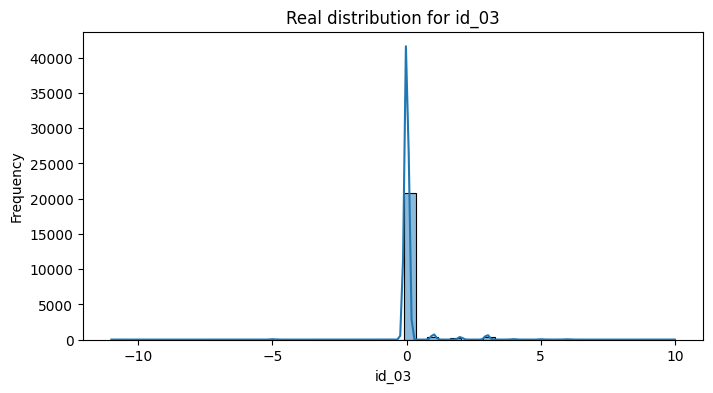

Variable id_09 : 34 valeur(s) unique(s), 24538 NaN


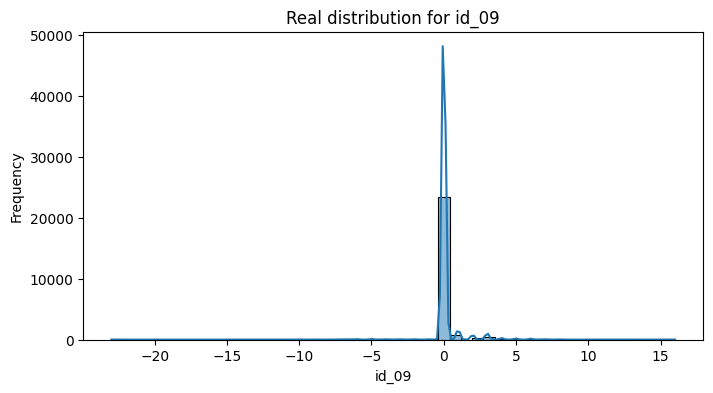

Variable id_10 : 48 valeur(s) unique(s), 24538 NaN


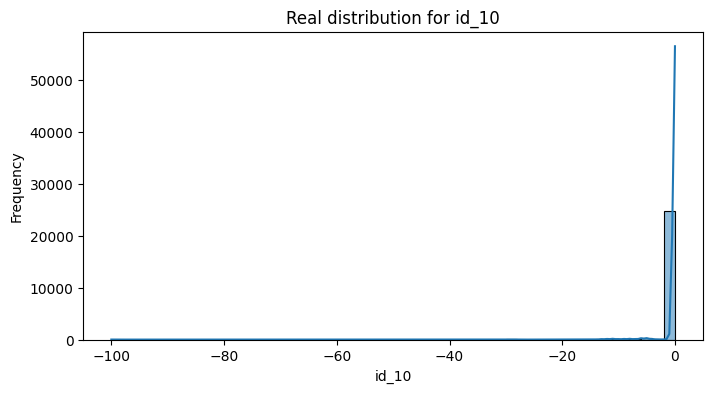

Variable id_11 : 293 valeur(s) unique(s), 1218 NaN


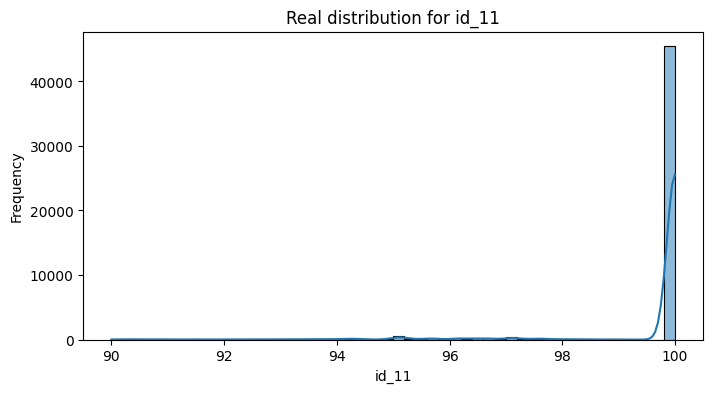

In [116]:
cols_to_check = ['id_03', 'id_09', 'id_10', 'id_11']

for col in cols_to_check:

    print(f"Variable {col} : {df_combined[col].nunique()} valeur(s) unique(s), {df_combined[col].isna().sum()} NaN")
    

    plt.figure(figsize=(8, 4))

    sns.histplot(df_combined[col].dropna(), bins=50, kde=True)
    plt.title(f"Real distribution for {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


We have a variable which majors in every variable.

For categorical variables now

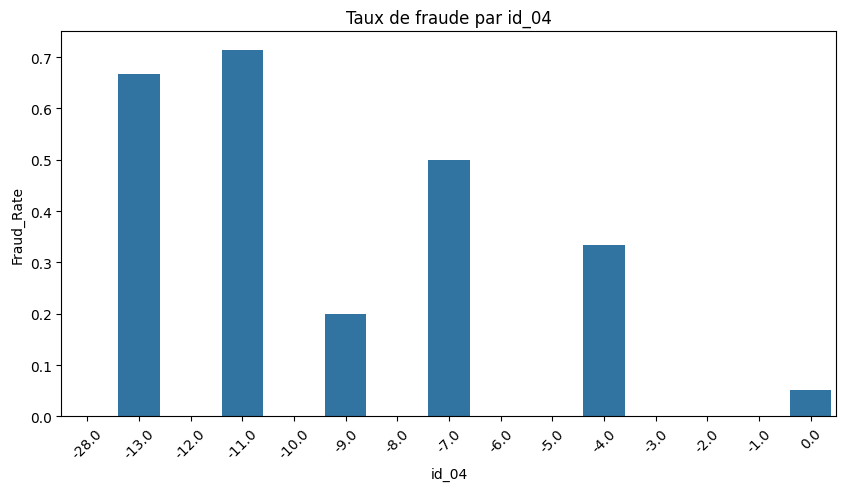

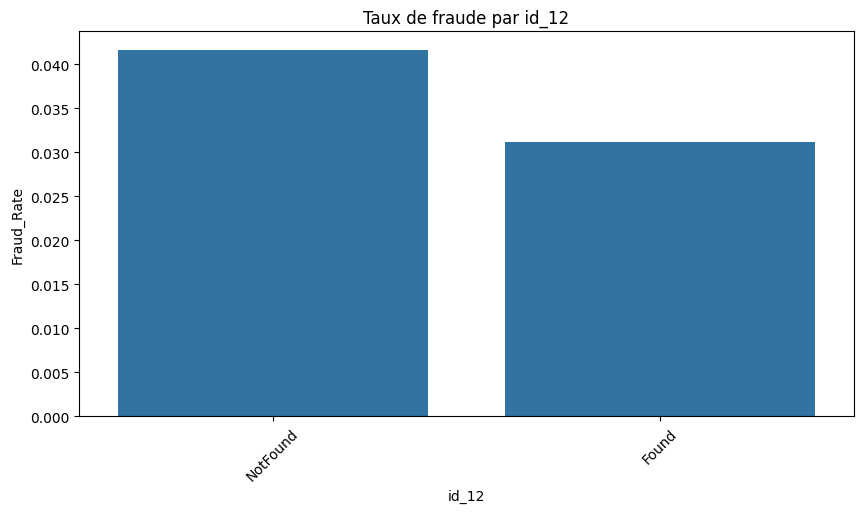

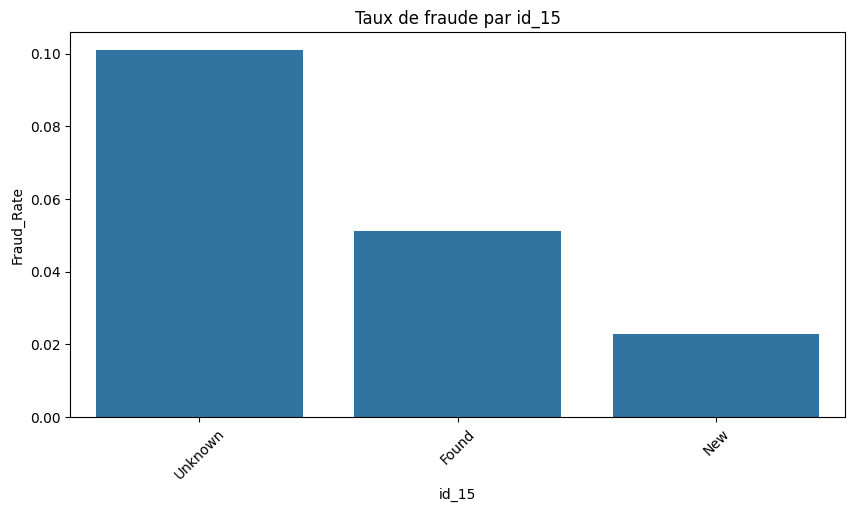

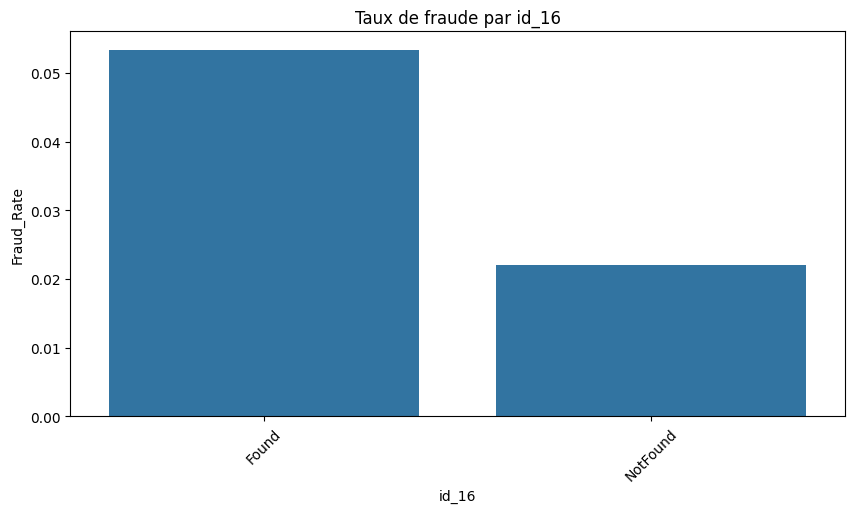

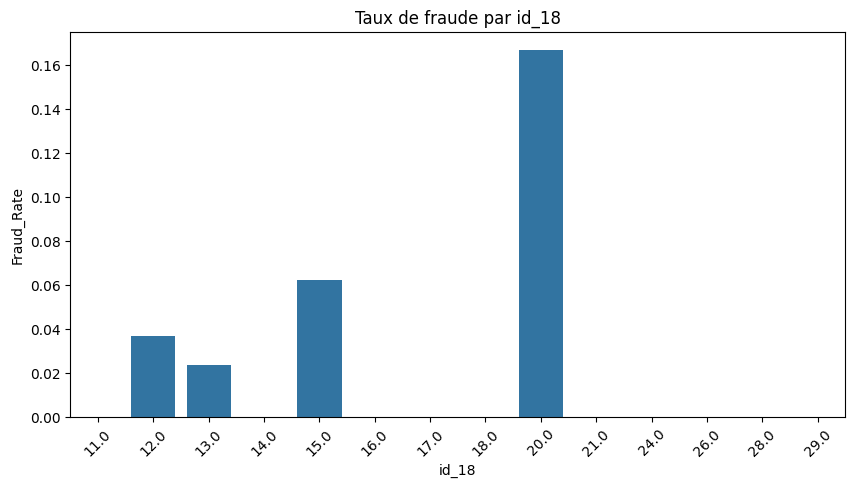

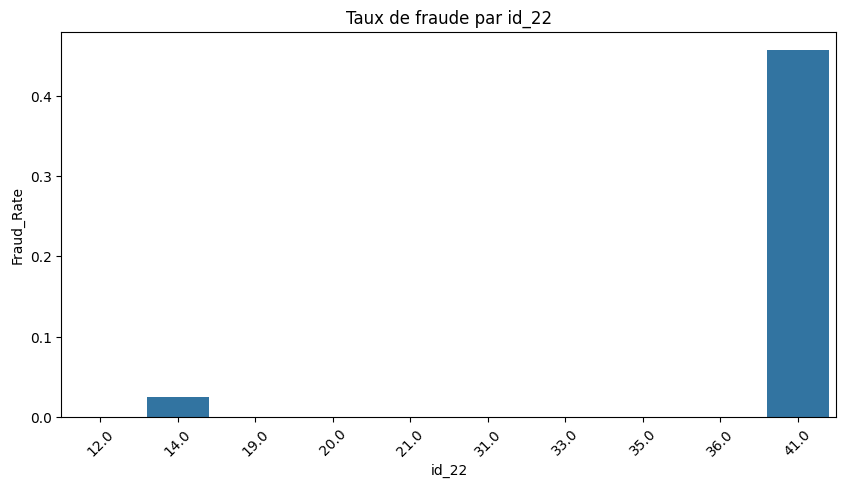

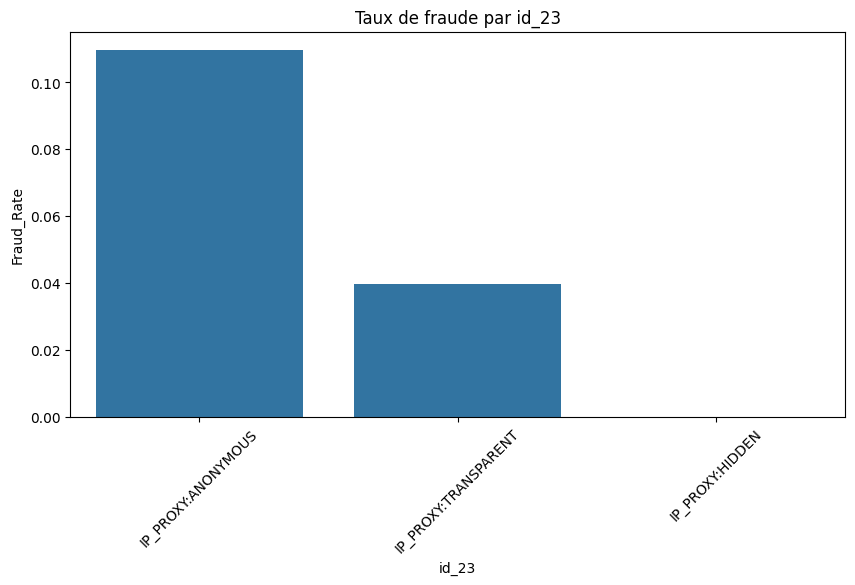

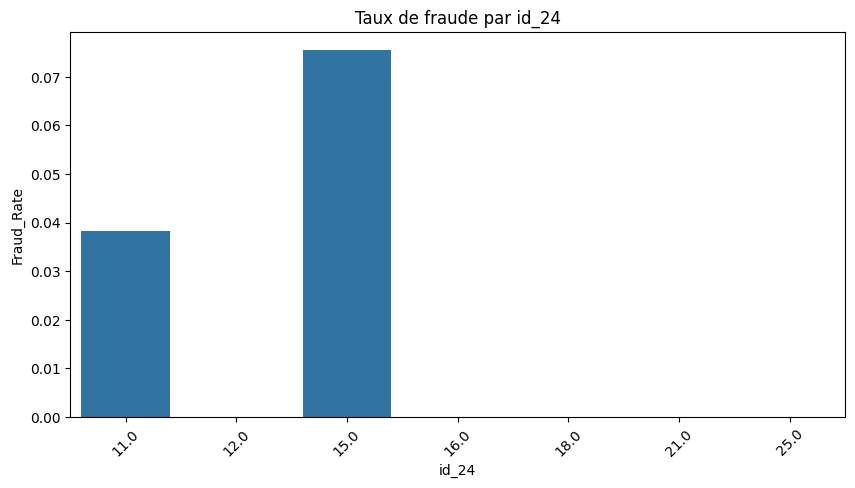

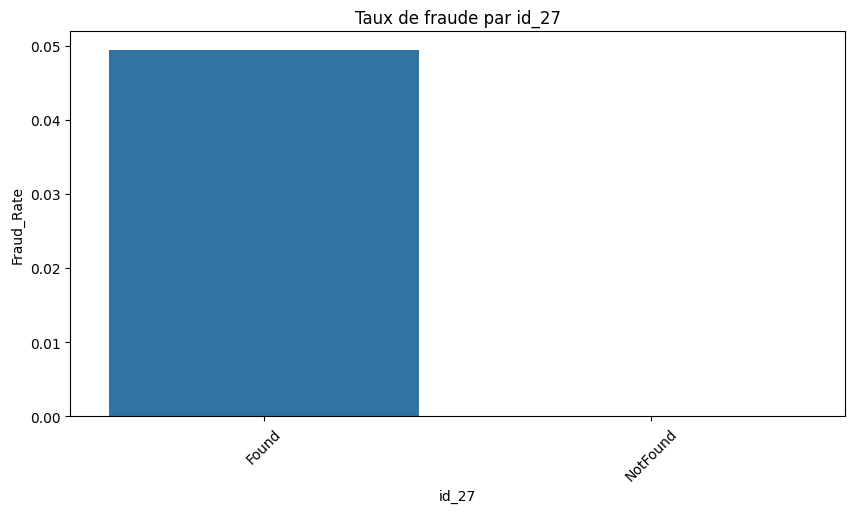

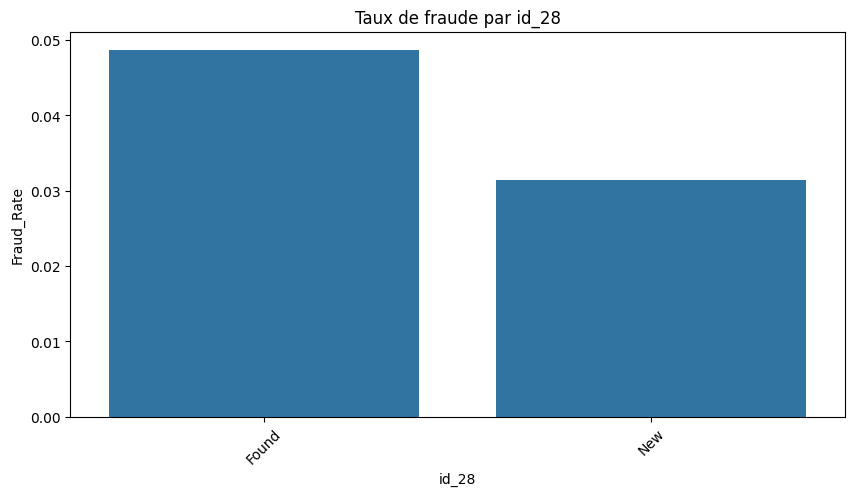

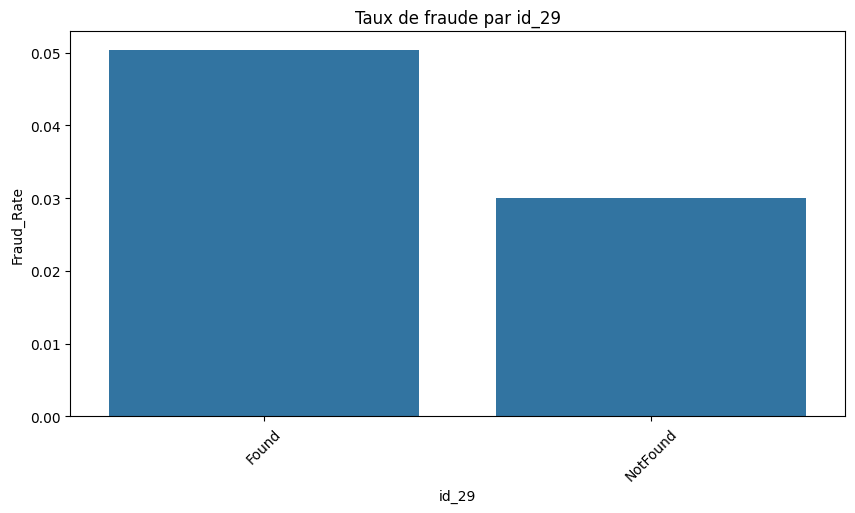

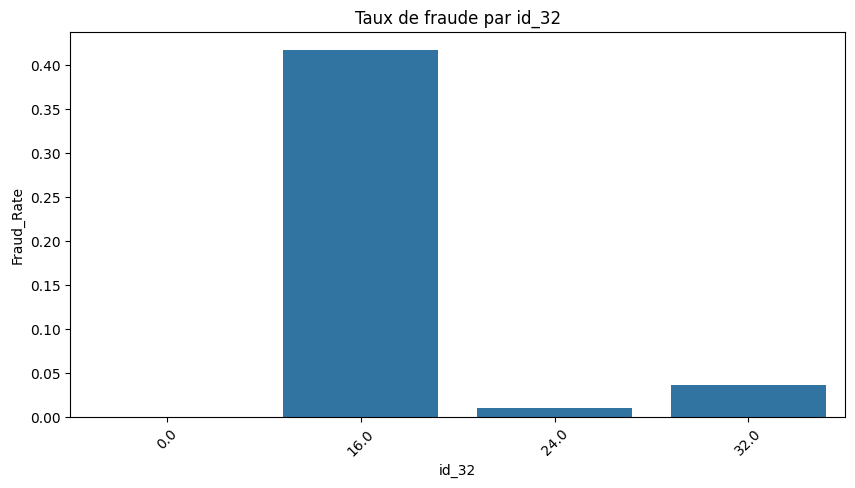

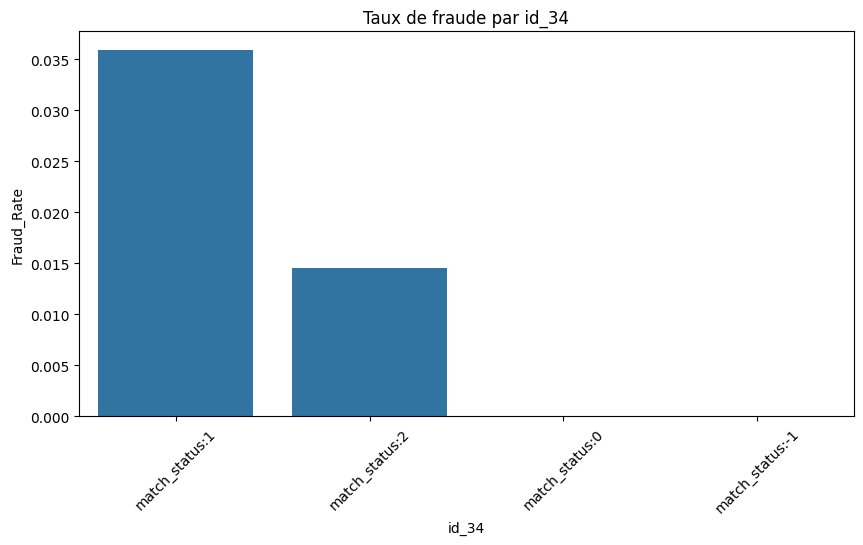

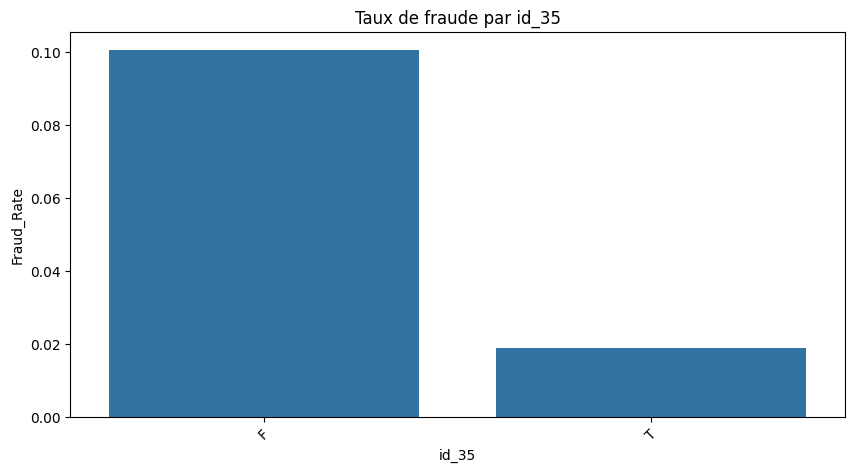

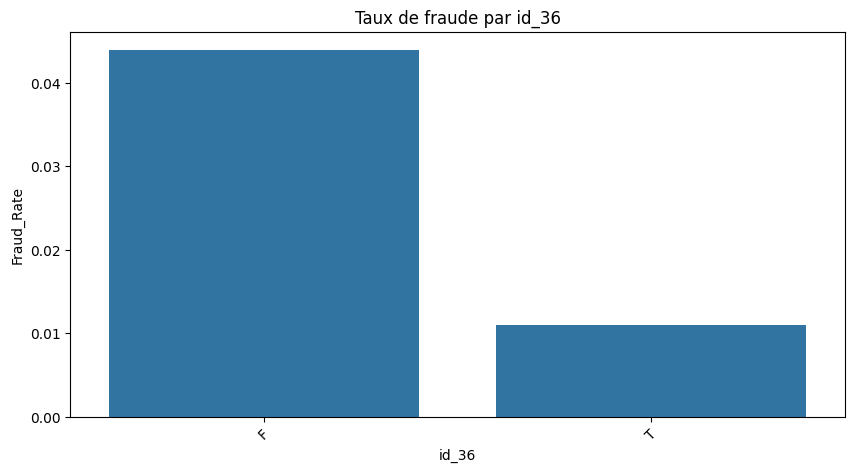

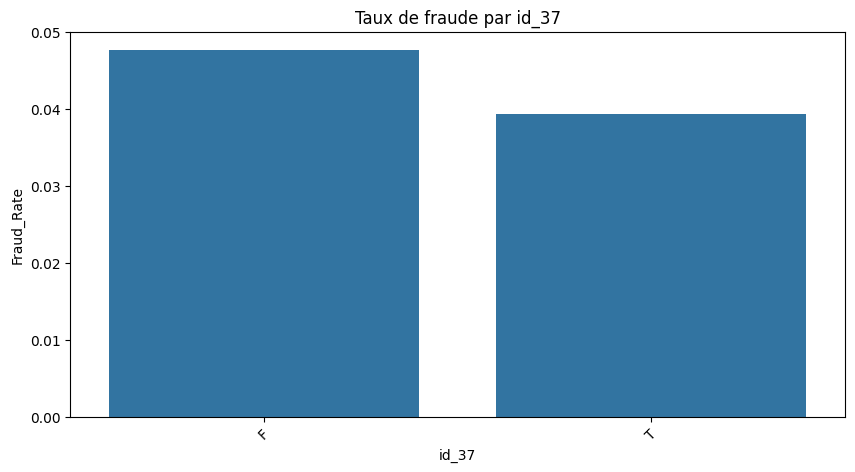

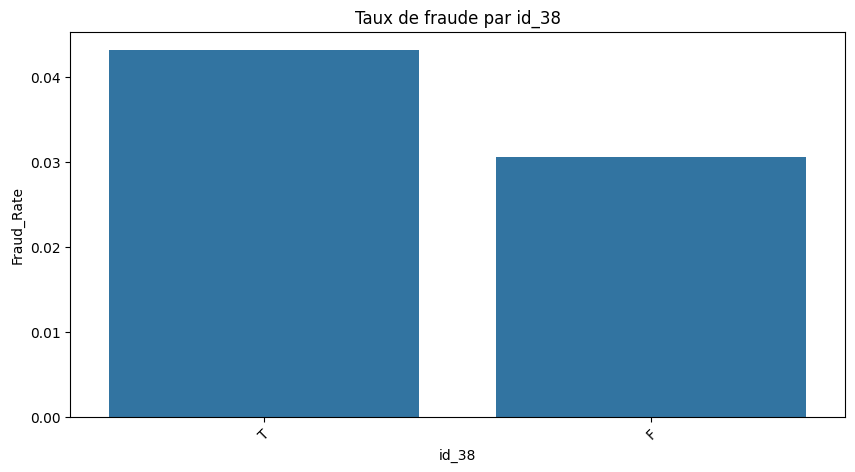

In [ ]:
id_cols_list = [col for col in df_combined.columns if col.startswith('id_') or col == 'isFraud']

cat_cols = [c for c in id_cols_list if df_combined[c].dtype == 'object' or df_combined[c].nunique() < 20]

cat_cols = [c for c in cat_cols if c != 'isFraud']


for col in cat_cols:

    data_plot = df_combined.groupby(col, observed=True)['isFraud'].mean().reset_index(name='Fraud_Rate')
    data_plot = data_plot.sort_values(by='Fraud_Rate', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=col, y='Fraud_Rate', data=data_plot)
    plt.xticks(rotation=45)
    plt.title(f"Taux de fraude par {col}")
    plt.show()

In [107]:
#Missing values check sorting

na_pourcentage = df_id.isnull().mean() * 100
na_pourcentage.index = df_id.columns
na_pourcentage = na_pourcentage.sort_values(ascending=False)
print(na_pourcentage)

id_24            96.446
id_25            96.192
id_21            96.176
id_07            96.170
id_08            96.170
id_26            96.170
id_23            96.168
id_27            96.168
id_22            96.168
id_18            68.952
id_03            56.354
id_04            56.354
id_09            49.076
id_10            49.076
id_33            31.542
id_30            26.090
id_32            26.086
id_34            25.918
id_14            25.010
id_13            17.894
DeviceInfo       11.388
id_16             7.626
id_06             5.564
id_05             5.564
id_20             3.538
id_19             3.534
id_17             3.510
id_31             2.774
DeviceType        2.674
id_02             2.658
id_28             2.436
id_29             2.436
id_15             2.436
id_11             2.436
id_35             2.436
id_36             2.436
id_37             2.436
id_38             2.436
id_01             0.000
id_12             0.000
TransactionID     0.000
dtype: float64


Some variables have the same percentage of missing values, we will check if it is on the same lines.

In [108]:

threshold = 0.90
high_nan_cols = [col for col in df_combined.columns if df_combined[col].isna().mean() > threshold]

print(f"Colonnes avec > 90% de NaN : {len(high_nan_cols)}")

# 2. Analyse comparative du taux de fraude
results = []

for col in high_nan_cols:
    # On crée un masque binaire : 1 si NaN, 0 si présent
    df_combined['is_nan'] = df_combined[col].isna()
    
    # On calcule le taux de fraude pour les deux groupes
    stats = df_combined.groupby('is_nan')['isFraud'].mean()
    
    results.append({
        'colonne': col,
        'taux_fraude_si_present': stats[False],
        'taux_fraude_si_nan': stats[True],
        'diff': stats[True] - stats[False] # Si positif, le NaN est plus suspect
    })

# 3. Affichage des résultats
df_results = pd.DataFrame(results).sort_values(by='diff', ascending=False)
print(df_results.head(10))

Colonnes avec > 90% de NaN : 9
  colonne  taux_fraude_si_present  taux_fraude_si_nan      diff
3   id_22                0.049342            0.040005 -0.009337
4   id_23                0.049342            0.040005 -0.009337
7   id_26                0.049342            0.040005 -0.009337
8   id_27                0.049342            0.040005 -0.009337
0   id_07                0.049423            0.040003 -0.009421
1   id_08                0.049423            0.040003 -0.009421
2   id_21                0.049669            0.039995 -0.009674
6   id_25                0.050167            0.039980 -0.010187
5   id_24                0.053667            0.039882 -0.013786


The fact that the frauder leaves a technical trace is a stronger indicator of fraud than the fact that he hides that trace.

In [109]:
cols = ['id_27', 'id_22', 'id_23']

ref_col = cols[0]

print(f"Référence : {ref_col}")
for col in cols[1:]:

    is_sync = df_id[col].isna().equals(df_id[ref_col].isna())
    print(f"{col} est synchronisé avec {ref_col} : {is_sync}")

Référence : id_27
id_22 est synchronisé avec id_27 : True
id_23 est synchronisé avec id_27 : True


In [111]:
df_combined['count_missing_tech_block'].value_counts()

count_missing_tech_block
6    48084
0     1765
1      146
2        5
Name: count, dtype: int64

<Axes: xlabel='count_missing_tech_block', ylabel='isFraud'>

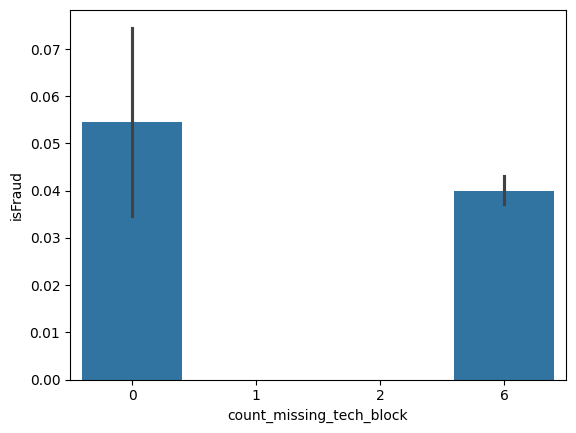

In [ ]:
sns.barplot(x='count_missing_tech_block', y='isFraud', data=df_combined)

When a transaction provides all its technical information (0 missing), it has a 7% probability of being fraudulent. Conversely, when it hides 6 pieces of technical information, this probability drops to 4%. Hiding this information reduces the risk of fraud by a factor of 3.5.

We could probably say that privacy protection tools or enterprise configurations, which systematically mask technical data, are correlated with trusted user profiles.

There are no constant columns. After sorting the data, approximately half are categories and the other half are numeric values. Following the boxplot, we were able to modify our numeric data. For our model, we will need to use the same data separation code, remembering to modify id30, id31, and id33. Some numeric variables have a higher representation than others. By checking the categorical values ​​via a bar plot, the difference between fraudulent and non-fraudulent values ​​is visible for all variables. Finally, many have the same missing values, which will be handled by XGBoost. We have many missing values ​​for approximately 9 columns (more than 95% missing values). We will not modify this either, as XGBoost handles it very well. However, the fraud rate for present values ​​and NaN values ​​for these variables is not distinguishable (only a maximum difference of -0.1). By looking at the number of missing values ​​per line, we notice that the fraud rate increases if there are more values ​​entered.

In [183]:

# Affiche le type de chaque colonne
print(df_id.dtypes.value_counts())

# Si tu veux voir précisément quelles colonnes posent problème :
non_numeric_cols_id = df_id.select_dtypes(exclude=[np.number]).columns
print(f"Colonnes non numériques restantes id: {list(non_numeric_cols_id)}")

float64    23
str        17
int64       1
Name: count, dtype: int64
Colonnes non numériques restantes id: ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [184]:
for i in non_numeric_cols_id:
    print("for", i, ":", df_id[i].nunique())

for id_12 : 2
for id_15 : 3
for id_16 : 2
for id_23 : 3
for id_27 : 2
for id_28 : 2
for id_29 : 2
for id_30 : 75
for id_31 : 130
for id_33 : 260
for id_34 : 4
for id_35 : 2
for id_36 : 2
for id_37 : 2
for id_38 : 2
for DeviceType : 2
for DeviceInfo : 1786


In [ ]:
BINARY_ID_COLS = ['id_12','id_27','id_28','id_29']

for i in BINARY_ID_COLS:
    print(df_id[i].value_counts())

id_12
NotFound    43247
Found        6753
Name: count, dtype: int64
id_23
IP_PROXY:TRANSPARENT    1206
IP_PROXY:ANONYMOUS       418
IP_PROXY:HIDDEN          292
Name: count, dtype: int64
id_27
Found       1915
NotFound       1
Name: count, dtype: int64
id_28
Found    26277
New      22505
Name: count, dtype: int64
id_29
Found       25462
NotFound    23320
Name: count, dtype: int64


All the variable with 2 values will be modified as binary variable.
For those with 3 and 4 values, we will perform a one hot encoding.

Fianlly, for id_30, id_31, id_33, we already modified it with 6 variables each, then we will also perform a one hot encoding.

For DeviceInfo, we will perform the same as id_30 for exemple, then we can do a one hot encoding.



In [164]:
print(df_id['DeviceInfo'].unique())

print(df_id['DeviceInfo'].isna().sum())

<StringArray>
[ 'SAMSUNG SM-G892A Build/NRD90M',                     'iOS Device',
                        'Windows',                              nan,
                          'MacOS',          'SM-G930V Build/NRD90M',
        'BLADE A602 Build/MRA58K', 'XT1635-02 Build/NPN26.118-22-2',
                           'Z970',          'SM-N920V Build/NRD90M',
 ...
  'SAMSUNG-SM-G920A Build/MMB29K',                       'SM-T807T',
                        'CAM-L23',                       'SM-T817T',
                       'SM-J727P',                      'SM-G550T2',
                          'VS985',           'LG-H815 Build/MRA58K',
                       'SM-G900P',  'SAMSUNG SM-J320M Build/LMY47V']
Length: 945, dtype: str
5694


In [166]:
def simplify_device_info(val):
    if pd.isna(val): return 'Missing'
    
    val = str(val).lower()
    
    if 'samsung' in val: return 'Samsung'
    if 'sm-' in val: return 'Samsung' # Beaucoup de SM- sont des Samsung
    if 'ios' in val or 'apple' in val or 'iphone' in val: return 'Apple'
    if 'windows' in val: return 'Windows'
    if 'mac' in val: return 'Mac'
    if 'lg' in val: return 'LG'
    if 'xt' in val or 'moto' in val: return 'Motorola'
    if 'blade' in val or 'zte' in val: return 'ZTE'
    if 'huawei' in val: return 'Huawei'
    
    return 'Other'

# On applique le nettoyage
df_combined['DeviceInfo_brand'] = df_combined['DeviceInfo'].apply(simplify_device_info)

# Maintenant, tu peux dropper l'ancienne colonne et utiliser LabelEncoder sur celle-ci
df_combined.drop(columns=['DeviceInfo'], inplace=True)

<Axes: xlabel='DeviceInfo_brand', ylabel='isFraud'>

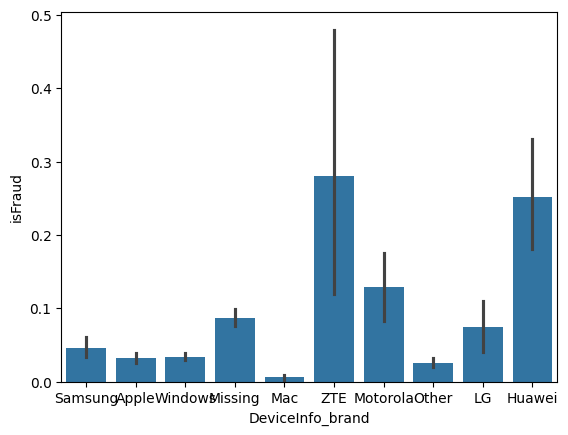

In [168]:
sns.barplot(x='DeviceInfo_brand', y='isFraud', data=df_combined)

Now we have an information that we can read correctly.